## Problem formulation

I am unemployed and expect to evaluate a finite number of job opportunities over a fixed time window.
Each opportunity can be scored using a rubric (salary, learning, stability, etc.).
I must decide when to stop searching and accept an employer.

### Hypothesis
A stopping strategy based on the exploration of ~37% of options, then accept the first option better than all seen so far, is optimal.

### What “better” means
I define a score function that maps employer attributes to a single number.


## Prime number 37: math foundations

37 is prime: it has exactly two positive divisors (1 and 37).
To solve this problem, we must define our variables:
* Let **$N$** be the total number of jobs we will interview for.
* Let **$S$** be the number of initial jobs we interview for and *reject* just to establish a baseline standard (the "exploration" phase).

The goal is to maximize the probability of picking the absolute best option. Based on the fundamental rules of optimal stopping, the probability of selecting the best option is the sum of the probabilities of selecting the best option at each step after our exploration phase $S$.

### Discrete Formula
The probability $P$ of picking the best option can be written as:

$$P(\text{pick best option}) = \frac{S}{N} \times \left(1 + \frac{1}{S+1} + \frac{1}{S+2} + \dots + \frac{1}{N-1}\right)$$

### Continuous Approximation & Calculus
As $N$ gets larger, we can approximate this summation using a definite integral, which simplifies to the natural logarithm:

$$P(\text{pick best option}) \approx \frac{S}{N} \ln\left(\frac{N}{S}\right)$$

To find the absolute maximum probability, we take the derivative of this function with respect to $S$ and set it to $0$ (finding the peak of the curve):

$$\frac{d}{dS} \left[ \frac{S}{N} \ln\left(\frac{N}{S}\right) \right] = 0$$

Using the product rule and chain rule, this simplifies to:

$$-\ln\left(\frac{S}{N}\right) - \left(\frac{S}{N} \times \frac{N}{S}\right) = 0$$
$$\ln\left(\frac{S}{N}\right) = -1$$

To solve for the optimal ratio of $S$ to $N$, we exponentiate both sides:

$$\frac{S}{N} = e^{-1} = \frac{1}{e} \approx 37\%$$

Thus, the math suggests we should reject the first 37% of jobs to set our standard, and then accept the very next job that beats that standard.


## Employer scoring model

Each employer has attributes normalized to [0, 1].
Score is a weighted sum:

Score = w_salary*Salary + w_learning*Learning + w_stability*Stability + w_remote*Remote + w_culture*Culture - w_commute*Commute

Weights reflect my priorities for every company/employer.


### Job Fit Scoring Formula

The total fit score is calculated using the following weighted linear combination:

$$\text{Fit} = 0.35 \cdot \text{Salary} + 0.30 \cdot \text{Learning} + 0.20 \cdot \text{Team} + 0.10 \cdot \text{Stability} + 0.05 \cdot \text{Remote} - 0.10 \cdot \text{Commute}$$


#### 1. What does $0.35 \times \text{Salary}$ actually mean?

In this term:
$$0.35 \cdot \text{Salary}$$

* **Salary** = *how good this employer is on salary* (normalized score)
* **0.35** = *how important salary is to you* (weight)

So the multiplication means:
> "Take the salary score and count **35% of it** toward the final decision."

#### 2. Where does 0.35 come from?

It comes from your choice, not from mathematics. The weights represent **relative importance**.

If your priorities are **Salary**, **Learning**, and **Team**, then decide the weights based on their impact:
* Salary is the **most important**.
* Learning is **almost as important**.
* Team is **important but slightly less**.

##### Weight Distribution Table

| Factor | Weight | Meaning |
| :--- | :--- | :--- |
| **Salary** | `0.35` | 35% of the decision |
| **Learning** | `0.30` | 30% of the decision |
| **Team** | `0.20` | 20% of the decision |
| **Stability** | `0.10` | 10% of the decision |
| **Remote** | `0.05` | 5% |
| **Commute** | `-0.10` | penalty (cost) |

**Note:** These positive weights **sum to 1**, ensuring the total score remains normalized (excluding the commute penalty).

In [31]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [32]:
def calculate_job_fit(salary, learning, team, stability, remote, commute):
    """
    Calculates a job fit score based on weighted criteria (1-10 scale recommended).
    """
    fit = (0.35 * salary) + (0.30 * learning) + (0.20 * team) + \
          (0.10 * stability) + (0.05 * remote) - (0.10 * commute)
    return round(fit, 2)

# Example usage:
score = calculate_job_fit(salary=9, learning=8, team=7, stability=9, remote=10, commute=2)
print(f"Total Job Fit Score: {score}")

Total Job Fit Score: 8.15


### How to Normalize Each Factor (Simple Rules)
Here’s a practical normalization scheme you can actually use during interviews.

#### 💰 Salary
Define a realistic range for your market.  
**Example:**
* **Minimum acceptable:** €2,500 $\rightarrow$ 0.0
* **Excellent offer:** €4,500 $\rightarrow$ 1.0

**Formula:**
$$\text{Salary Score} = \frac{\text{Offer} - 2500}{4500 - 2500}$$

In [33]:
def normalize_salary(offer, min_val=2500, max_val=4500):
    # Clips the score between 0 and 1 so outliers don't break your logic
    score = (offer - min_val) / (max_val - min_val)
    return max(0, min(1, score)) 

# Test it out
print(f"Score for €3,500: {normalize_salary(3500)}")

Score for €3,500: 0.5


#### 📚 Learning

Score can be based on:
* Exposure to new technologies at work
* Mentorship
* Ownership

| Learning quality | Score |
| :--- | :--- |
| Mostly maintenance | `0.2` |
| Some growth | `0.5` |
| Strong learning path | `0.8` |
| Exceptional | `1.0` |

#### 👥 Team quality

Can be based on:
* Interview clarity
* Technical depth
* Communication
* Respect

| Team impression | Score |
| :--- | :--- |
| Disorganized | `0.3` |
| OK | `0.5` |
| Strong | `0.8` |
| Excellent | `1.0` |

#### 🏢 Stability

| Company situation | Score |
| :--- | :--- |
| Startup / risky | `0.4` |
| Growing | `0.6` |
| Established | `0.8` |
| Very stable | `1.0` |

#### 🌍 Remote

| Work model | Score |
| :--- | :--- |
| On-site | `0.2` |
| Hybrid | `0.6` |
| Fully remote | `1.0` |

#### 🚗 Commute (penalty)

| Commute | Score |
| :--- | :--- |
| 90+ min | `1.0` |
| 60 min | `0.7` |
| 30 min | `0.4` |
| Remote | `0.0` |

**(Remember: commute is subtracted.)**

#### 3️⃣ Example: Evaluate 3 real-looking employers

##### Employer A — QA Automation (local company)
* **Salary:** €3,200 $\rightarrow$ `0.35`
* **Learning:** mostly test automation $\rightarrow$ `0.45`
* **Team:** decent $\rightarrow$ `0.6`
* **Stability:** established $\rightarrow$ `0.8`
* **Remote:** hybrid $\rightarrow$ `0.6`
* **Commute:** 60 min $\rightarrow$ `0.7`

##### Employer B — Data Engineer (international)
* **Salary:** €4,200 $\rightarrow$ `0.85`
* **Learning:** pipelines, cloud, mentoring $\rightarrow$ `0.9`
* **Team:** strong $\rightarrow$ `0.85`
* **Stability:** growing $\rightarrow$ `0.7`
* **Remote:** fully remote $\rightarrow$ `1.0`
* **Commute:** remote $\rightarrow$ `0.0`

##### Employer C — QA Manual
* **Salary:** €3,600 $\rightarrow$ `0.55`
* **Learning:** mixed $\rightarrow$ `0.7`
* **Team:** excellent $\rightarrow$ `0.9`
* **Stability:** established $\rightarrow$ `0.8`
* **Remote:** hybrid $\rightarrow$ `0.6`
* **Commute:** 30 min $\rightarrow$ `0.4`

In [34]:
import pandas as pd

# Define the weights from our previous steps
weights = {
    'Salary': 0.35, 'Learning': 0.30, 'Team': 0.20, 
    'Stability': 0.10, 'Remote': 0.05, 'Commute': 0.10
}

data = {
    'Employer A': [0.35, 0.45, 0.6, 0.8, 0.6, 0.7],
    'Employer B': [0.85, 0.9, 0.85, 0.7, 1.0, 0.0],
    'Employer C': [0.55, 0.7, 0.9, 0.8, 0.6, 0.4]
}

df = pd.DataFrame(data, index=['Salary', 'Learning', 'Team', 'Stability', 'Remote', 'Commute'])

# Calculate Final Score: (Sum of Weighted Factors) - (Commute Penalty * Weight)
def calculate_total(col):
    positive_factors = col.iloc[:-1].multiply(pd.Series(weights)).sum()
    penalty = col.iloc[-1] * weights['Commute']
    return round(positive_factors - penalty, 3)

df.loc['TOTAL SCORE'] = df.apply(calculate_total)
df

,Employer A,Employer B,Employer C
Salary,0.350,0.850,0.550
Learning,0.450,0.900,0.700
Team,0.600,0.850,0.900
Stability,0.800,0.700,0.800
Remote,0.600,1.000,0.600
Commute,0.700,0.000,0.400
TOTAL SCORE,0.418,0.857,0.652


Each employer was evaluated using a normalized multi‑criteria Fit Score reflecting salary, learning potential, and team quality as primary factors. This allowed a consistent ranking of opportunities and enabled the application of an optimal stopping strategy.

In [35]:
def number_to_uppercase_letters(number):
    """Convert an integer (0, 1, 2, ...) into Excel-style uppercase letters (A, B, ..., Z, AA, AB...)."""
    letters = ""
    while True:
        number, remainder = divmod(number, 26)
        letters = chr(65 + remainder) + letters
        if number == 0:
            break
        number -= 1
    return letters

def generate_employers(number_of_employers=30, random_seed=42):
    # Create a reproducible random number generator
    random_number_generator = np.random.default_rng(random_seed)

    # Create employer names: A, B, C, ..., Z, AA, AB, ...
    employer_names = [
        number_to_uppercase_letters(i)
        for i in range(number_of_employers)
    ]

    # Build the DataFrame
    employers_dataframe = pd.DataFrame({
        "employer": employer_names,
        "salary":   random_number_generator.uniform(0, 1, number_of_employers),
        "learning": random_number_generator.uniform(0, 1, number_of_employers),
        "stability": random_number_generator.uniform(0, 1, number_of_employers),
        "remote":   random_number_generator.uniform(0, 1, number_of_employers),
        "culture":  random_number_generator.uniform(0, 1, number_of_employers),
        "commute":  random_number_generator.uniform(0, 1, number_of_employers),
    })

    return employers_dataframe

generate_employers()

,employer,salary,learning,stability,remote,culture,commute
0,A,0.773956,0.744762,0.668403,0.152312,0.584098,0.826292
1,B,0.438878,0.967510,0.471096,0.696320,0.649847,0.896161
2,C,0.858598,0.325825,0.565236,0.446156,0.084444,0.140249
3,D,0.697368,0.370460,0.764999,0.381021,0.415807,0.554036
4,E,0.094177,0.469556,0.634718,0.301512,0.041614,0.108576
5,F,0.975622,0.189471,0.553579,0.630283,0.493991,0.672240
6,G,0.761140,0.129922,0.559207,0.361813,0.329861,0.281234
7,H,0.786064,0.475705,0.303950,0.087650,0.144524,0.659423
8,I,0.128114,0.226909,0.030818,0.118006,0.103403,0.726995
9,J,0.450386,0.669814,0.436717,0.961898,0.587645,0.768647


### Using real employers (recommended)
Replace the synthetic generator with a small table you fill manually:
- salary (normalized)
- learning potential
- stability
- remote/hybrid fit
- culture/team fit
- commute/time cost

Normalize each to [0,1], then compute fit_score with your weights.


In [36]:
# Define a function to generate a dataframe of employers with random attributes normalized to [0,1]
# This function is here to create synthetic data for simulating job opportunities
def generate_employers(N=30, seed=42):
    # Create a random number generator with a fixed seed for reproducible results
    # This ensures the same random data is generated each time for consistency in simulations
    rng = np.random.default_rng(seed)
    # Create a pandas DataFrame with columns for each employer attribute
    # Each attribute is filled with N random uniform values between 0 and 1
    # This simulates diverse employer characteristics
    df = pd.DataFrame({
        "salary": rng.uniform(0, 1, N),
        "learning": rng.uniform(0, 1, N),
        "stability": rng.uniform(0, 1, N),
        "remote": rng.uniform(0, 1, N),
        "culture": rng.uniform(0, 1, N),
        "commute": rng.uniform(0, 1, N),
    })
    # Return the generated dataframe
    return df

# Define a dictionary of weights for scoring employers
# These weights reflect personal priorities in the job search (e.g., salary is most important)
# The commute weight is noted to be subtracted, as higher commute is worse
weights = {
    "salary": 0.30,
    "learning": 0.25,
    "stability": 0.15,
    "remote": 0.15,
    "culture": 0.15,
    "commute": 0.20,  # subtract
}

# Define a function to calculate scores for employers based on attributes and weights
# This implements the scoring model described in the notebook's employer scoring section
def score_employers(df, w):
    # Compute the score as a weighted sum of attributes, subtracting the commute term
    # This formula combines all attributes into a single score for comparison
    score = (
        w["salary"]*df["salary"]
        + w["learning"]*df["learning"]
        + w["stability"]*df["stability"]
        + w["remote"]*df["remote"]
        + w["culture"]*df["culture"]
        - w["commute"]*df["commute"]
    )
    # Create a copy of the input dataframe to avoid modifying it directly
    out = df.copy()
    # Add the calculated score as a new column to the dataframe
    out["score"] = score
    # Return the dataframe with the added score column
    return out

# Generate a dataframe of 30 employers, score them using the defined weights, and assign to variable df
# This creates the main dataset for analysis and plotting in subsequent cells
df = score_employers(generate_employers(30), weights)

# Display the first 5 rows of the dataframe to verify the data and scores
# This is for quick inspection and debugging
df.head()

,salary,learning,stability,remote,culture,commute,score
0,0.773956,0.744762,0.668403,0.152312,0.584098,0.826292,0.463841
1,0.438878,0.967510,0.471096,0.696320,0.649847,0.896161,0.466898
2,0.858598,0.325825,0.565236,0.446156,0.084444,0.140249,0.475361
3,0.697368,0.370460,0.764999,0.381021,0.415807,0.554036,0.425292
4,0.094177,0.469556,0.634718,0.301512,0.041614,0.108576,0.270604


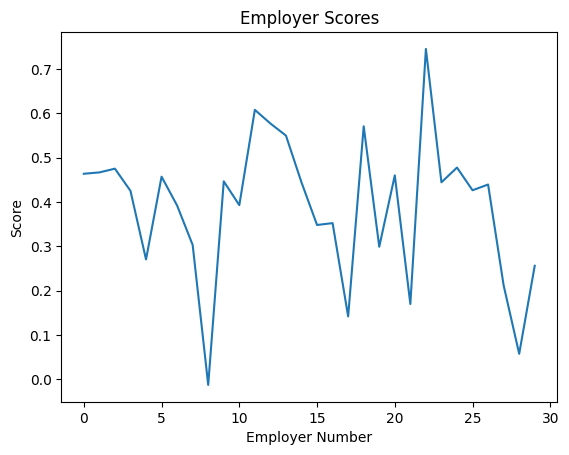

In [37]:
plt.plot(df.index, df['score'])
plt.xlabel('Employer Number')
plt.ylabel('Score')
plt.title('Employer Scores')
plt.show()

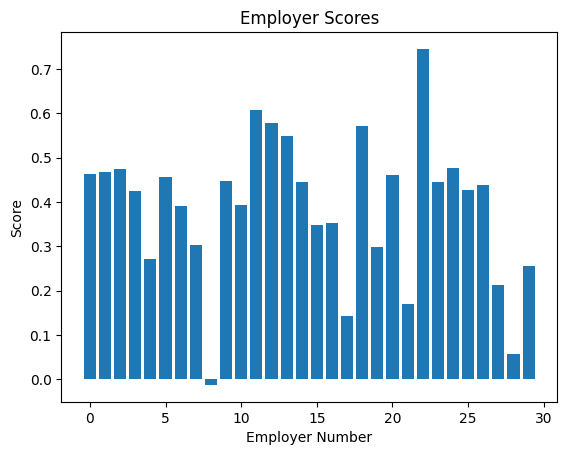

In [38]:
plt.bar(df.index, df['score'])
plt.xlabel('Employer Number')
plt.ylabel('Score')
plt.title('Employer Scores')
plt.show()

## The 37% rule

Let N be the number of employers I will evaluate.
Let S = floor(N / e) ≈ floor(0.37N).

1) Reject the first S employers, but remember the best score seen.
2) Accept the first later employer whose score exceeds that best-so-far.

We evaluate performance via simulation:
- probability of selecting the best employer
- average rank of selected employer
- regret (best_score - chosen_score)


In [39]:
def choose_employer(scores):
    # Calculate the total number of scores (employers) in the list
    N = len(scores)
    # Compute the rejection threshold r as the floor of N divided by e (approximately 37% of N)
    r = int(N / math.e)
    # Find the best score among the first r scores; if r is 0, set to negative infinity
    best_so_far = max(scores[:r]) if r > 0 else -float("inf")
    # Iterate through the remaining scores starting from index r
    for i in range(r, N):
        # If the current score is better than the best seen so far, return its index
        if scores[i] > best_so_far:
            return i
    # If no better score is found, return the index of the last employer
    return N - 1

def choose_first(scores):
    # Always choose the first employer (index 0)
    return 0

def choose_last(scores):
    # Always choose the last employer (index N-1)
    return len(scores) - 1

def choose_random(scores):
    # Choose a random employer index between 0 and N-1
    return random.randrange(len(scores))

In [40]:
def evaluate_once(N=30, seed=None):
    # Generate a dataframe of N employers with random attributes, score them using the predefined weights, and optionally use a provided seed for reproducibility
    df = score_employers(generate_employers(N, seed=seed if seed is not None else random.randint(0, 10**9)), weights)
    # Extract the scores as a numpy array for efficient numerical operations
    scores = df["score"].to_numpy()
    # Find the index of the best (maximum) score in the array
    best_idx = int(np.argmax(scores))
    # Get the best score value as a float
    best_score = float(scores[best_idx])
    
    # Define a dictionary mapping strategy names to their corresponding choice functions
    strategies = {
        "employer_37pct": choose_employer,
        "first": choose_first,
        "last": choose_last,
        "random": choose_random,
    }
    
    # Initialize an empty list to store results for each strategy
    results = []
    # Loop over each strategy name and its function
    for name, fn in strategies.items():
        # Apply the strategy function to the scores to get the chosen employer's index
        idx = fn(scores)
        # Get the score of the chosen employer as a float
        chosen_score = float(scores[idx])
        # Calculate the rank of the chosen score (1 being the best, higher numbers worse); count how many scores are better than chosen
        rank = int(np.sum(scores > chosen_score) + 1)  # 1 = best
        # Append a dictionary with results for this strategy to the results list
        results.append({
            "strategy": name,
            "chosen_idx": idx,
            "best_idx": best_idx,
            "picked_best": int(idx == best_idx),
            "rank": rank,
            "regret": best_score - chosen_score,
        })
    # Convert the list of result dictionaries to a pandas DataFrame and return it
    return pd.DataFrame(results)

# Call the function with N=30 and seed=1 to evaluate strategies once and display the results
evaluate_once(30, seed=1)

,strategy,chosen_idx,best_idx,picked_best,rank,regret
0,employer_37pct,12,26,0,4,0.065179
1,first,0,26,0,25,0.274985
2,last,29,26,0,6,0.107221
3,random,24,26,0,3,0.032026


## Practical version for real job searching

1) Decide a time window (e.g., 8 weeks) and estimate N serious opportunities.
2) For the first ~37% of that window, interview and learn—do not accept.
3) Build your “best so far” benchmark using your scoring rubric.
4) After that point, accept the first employer that beats your benchmark.

This is not a guarantee—it’s a rational strategy under clear assumptions.


In [41]:
def simulate(trials=3000, N=30):
    frames = [evaluate_once(N=N, seed=t) for t in range(trials)]
    res = pd.concat(frames, ignore_index=True)

    summary = res.groupby("strategy").agg(
        picked_best_rate=("picked_best", "mean"),
        avg_rank=("rank", "mean"),
        avg_regret=("regret", "mean"),
    ).reset_index()

    return res, summary

res, summary = simulate(trials=2000, N=30)
summary.sort_values("picked_best_rate", ascending=False)


,strategy,picked_best_rate,avg_rank,avg_regret
0,employer_37pct,0.3890,6.7990,0.128403
3,random,0.0390,15.5340,0.293124
1,first,0.0365,15.4660,0.292419
2,last,0.0325,15.8425,0.298800


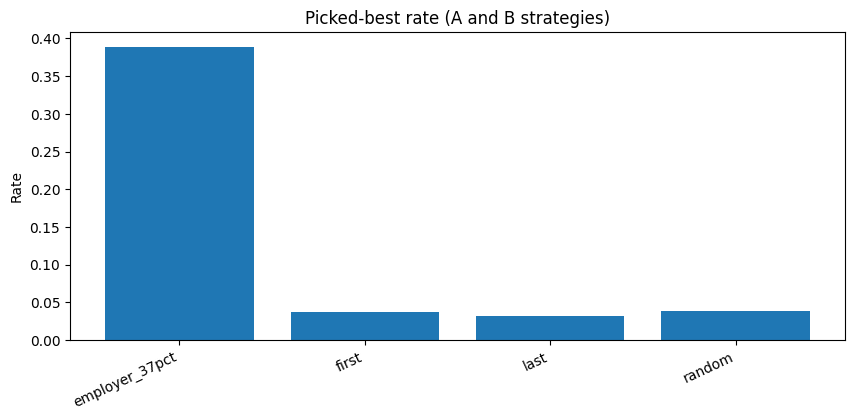

In [42]:
plt.figure(figsize=(10,4))
plt.bar(summary["strategy"], summary["picked_best_rate"])
plt.title("Picked-best rate (A and B strategies)")
plt.ylabel("Rate")
plt.xticks(rotation=25, ha="right")
plt.show()
